## Simple Workflow of Graph

In [1]:
def function3(input3):
    return input3

In [2]:
def function1(state):
    state["message"] = state["message"] + " from first function"
    return state

def function2(state):
    state["message"] = state["message"] + " from second function"
    return state

In [3]:
from langgraph.graph import StateGraph

In [4]:
from typing import TypedDict
from langgraph.graph import StateGraph

class GraphState(TypedDict):
    message: str

workflow1 = StateGraph(GraphState)

In [5]:
workflow1.add_node("function1", function1)

In [6]:
workflow1.add_node("function2",function2)

In [7]:
workflow1.add_edge("function1", "function2")

In [8]:
workflow1.set_entry_point("function1")

In [9]:
workflow1.set_finish_point("function2")

In [10]:
app1=workflow1.compile()

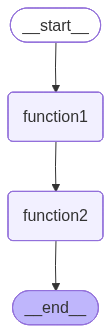

In [11]:
from IPython.display import Image, display

try:
    display(Image(app1.get_graph().draw_mermaid_png()))
except Exception as e:
    # This requires some extra dependencies and is optional
    print(e)

In [12]:
input_data = {"message": "hi this is sankalp"}

In [13]:
for output in app1.stream(input_data):
    for key, value in output.items():
        print(f"Here is output from {key}")
        print("_____________")
        print(value)
        print("\n")

Here is output from function1
_____________
{'message': 'hi this is sankalp from first function'}


Here is output from function2
_____________
{'message': 'hi this is sankalp from first function from second function'}




## Create workflow with llm

In [14]:
from langchain_huggingface import HuggingFaceEmbeddings
embeddings = HuggingFaceEmbeddings(model = "sentence-transformers/all-MiniLM-L6-v2")

In [15]:
import os
from dotenv import load_dotenv
load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
os.environ["GROQ_API_KEY"] = GROQ_API_KEY

In [16]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="llama-3.1-8b-instant")

In [17]:
llm.invoke("hi").content

'How can I assist you today?'

In [18]:
def function1(state):
    llm = ChatGroq(model_name="llama-3.1-8b-instant")
    response = llm.invoke(state["message"]).content
    return {"message": response}

In [19]:
def function2(state):
    upper_case = state["message"].upper()
    return {"message": upper_case}

In [20]:
from typing import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    message: str

workflow2 = StateGraph(AgentState)

In [21]:
workflow2.add_node("llm", function1)

In [22]:
workflow2.add_node("upper_string", function2)

In [23]:
workflow2.add_edge("llm", "upper_string")

In [24]:
workflow2.set_entry_point("llm")
workflow2.set_finish_point("upper_string")

In [25]:
app2 = workflow2.compile()

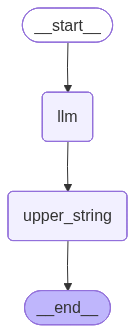

In [26]:
from IPython.display import Image, display

try:
    display(Image(app2.get_graph().draw_mermaid_png()))
except Exception as e:
    # This requires some extra dependencies and is optional
    print(e)

In [27]:
app2.invoke({"message": "what is name of first indian prime minister?"})

{'message': 'THE NAME OF THE FIRST INDIAN PRIME MINISTER WAS JAWAHARLAL NEHRU. HE SERVED AS THE FIRST PRIME MINISTER OF INDIA FROM AUGUST 15, 1947, UNTIL HIS DEATH ON MAY 27, 1964.'}

In [28]:
print(app2.invoke({"message": "What is GenAI explain in detail?"}))

{'message': '**GENAI: GENERALIZED ARTIFICIAL INTELLIGENCE**\n\nGENAI, ALSO KNOWN AS GENERALIZED ARTIFICIAL INTELLIGENCE OR GENERAL AI, IS A HYPOTHETICAL FORM OF ARTIFICIAL INTELLIGENCE (AI) THAT IS CAPABLE OF PERFORMING ANY INTELLECTUAL TASK THAT A HUMAN BEING CAN. IT IS A HIGHLY ADVANCED AI SYSTEM THAT POSSESSES A LEVEL OF INTELLIGENCE, REASONING, AND PROBLEM-SOLVING CAPABILITIES THAT ARE EQUIVALENT TO OR EVEN SURPASS THOSE OF A HUMAN BEING.\n\n**KEY CHARACTERISTICS OF GENAI:**\n\n1. **GENERAL KNOWLEDGE**: GENAI HAS A VAST AND GENERAL KNOWLEDGE BASE THAT INCLUDES INFORMATION FROM VARIOUS DOMAINS, INCLUDING SCIENCE, HISTORY, PHILOSOPHY, AND MORE.\n2. **REASONING AND PROBLEM-SOLVING**: GENAI IS CAPABLE OF REASONING, ANALYZING, AND SOLVING COMPLEX PROBLEMS USING LOGICAL AND CRITICAL THINKING.\n3. **LEARNING AND ADAPTATION**: GENAI CAN LEARN FROM EXPERIENCE, ADAPT TO NEW SITUATIONS, AND UPDATE ITS KNOWLEDGE AND BELIEFS ACCORDINGLY.\n4. **CREATIVITY**: GENAI IS CREATIVE AND CAN GENERATE NE

In [29]:
input_data = {"message": "What is name of first Indian Prime Minister of India?"}

In [30]:
for output in app2.stream(input_data):
    for key, value in output.items():
        print(f"Here is output from {key}")
        print("_____________")
        print(value)
        print("\n")

Here is output from llm
_____________
{'message': 'The first Indian Prime Minister of India was Jawaharlal Nehru.'}


Here is output from upper_string
_____________
{'message': 'THE FIRST INDIAN PRIME MINISTER OF INDIA WAS JAWAHARLAL NEHRU.'}




## Create output token counter

In [31]:
def function3(state):
    token = state["message"].split()
    token_number = len(token)
    return {"message": f"Total token number is {token_number}"}

In [32]:
from typing import TypedDict
from langgraph.graph import StateGraph

class GraphState3(TypedDict):
    message: str

workflow3 = StateGraph(GraphState3)

workflow3.add_node("llm", function1)
workflow3.add_node("token_counter", function3)

workflow3.add_edge("llm", "token_counter")

workflow3.set_entry_point("llm")
workflow3.set_finish_point("token_counter")

app3 = workflow3.compile()

In [33]:
app3.invoke({"message": "What is name of first indian prime minister?"})

{'message': 'Total token number is 11'}

In [34]:
app3.invoke({"message": "What is genai explain in detail?"})

{'message': 'Total token number is 521'}

## Integrating RAG with LangGraph

In [35]:
from langchain_huggingface import HuggingFaceEmbeddings
embeddings = HuggingFaceEmbeddings(model = "sentence-transformers/all-MiniLM-L6-v2")

In [53]:
from langchain_groq import ChatGroq
llm = ChatGroq(model = "llama-3.1-8b-instant")

In [54]:
llm.invoke("hi").content

'Hello. Is there something I can help you with or would you like to chat?'

In [38]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_community.document_loaders import TextLoader, DirectoryLoader
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [60]:
loader = TextLoader("D:\\GenAI-Notes\\LangGraph\\india_gdp_information.txt")
docs = loader.load()
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 100, 
    chunk_overlap = 50
)

new_docs = text_splitter.split_documents(documents = docs)
doc_strings = [doc.page_content for doc in new_docs]

db = Chroma.from_documents(new_docs, embeddings)
retriever = db.as_retriever(search_kwargs = {"k": 3})

query = "What is meta llama3?"
docs = retriever.invoke(query)
print(docs[0].metadata)
print(docs[0].page_content)

for doc in docs:
    print(doc)

{'source': 'D:\\GenAI-Notes\\LangGraph\\india_gdp_information.txt'}
Future Outlook
page_content='Future Outlook' metadata={'source': 'D:\\GenAI-Notes\\LangGraph\\india_gdp_information.txt'}
page_content='Future Outlook' metadata={'source': 'D:\\GenAI-Notes\\LangGraph\\india_gdp_information.txt'}
page_content='India is expected to continue growing due to: - Rapid digital' metadata={'source': 'D:\\GenAI-Notes\\LangGraph\\india_gdp_information.txt'}


In [61]:
def function_1(AgentState):
    message = AgentState["messages"]
    question = message[-1]

    complete_prompt = "Your task is to provide only the brief answer based on the user query." \
    "Don't include too much reasonsing. Following is the query: " + question

    response = llm.invoke(complete_prompt)
    AgentState['messages'].append(response.content) # Appending LLM call response to the AgentState
    print(AgentState)

    return  AgentState

In [62]:
AgentState={}

In [63]:
AgentState["messages"]=[]

In [64]:
AgentState

{'messages': []}

In [65]:
AgentState["messages"].append("hi, how are you?")

In [66]:
AgentState["messages"].append("hi, what are you doing?")

In [67]:
AgentState

{'messages': ['hi, how are you?', 'hi, what are you doing?']}

In [68]:
def function_2(AgentState):
    message = AgentState["messages"]
    question = message[-1]

    complete_prompt = "Your task is to provide only the brief answer based on the user query." \
    "Don't include too much reasonsing. Following is the query: " + question

    response = llm.invoke(complete_prompt)
    AgentState['messages'].append(response.content) # Appending LLM call response to the AgentState
    print(AgentState)

    return  AgentState

In [69]:
from langgraph.graph import StateGraph
from typing import TypedDict

class MessagesState(TypedDict):
    messages: list

workflow4 = StateGraph(MessagesState)

workflow4.add_node("LLM", function_1)
workflow4.add_node("RAGtool", function_2)

workflow4.add_edge("LLM", "RAGtool")

workflow4.set_entry_point("LLM")
workflow4.set_finish_point("RAGtool")

app4 = workflow4.compile()

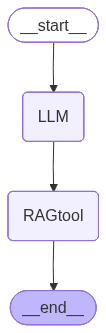

In [70]:
from IPython.display import Image, display

try:
    display(Image(app4.get_graph().draw_mermaid_png()))
except Exception as e:
    # This requires some extra dependencies and is optional
    print(e)

In [71]:
inputs = {"messages": ["Tell me about llama3 model"]}

In [72]:
for output in app4.stream(inputs):
    for key, value in output.items():
        print(f"Output from node {key}")
        print("---")
        print(value)
        print("\n")

{'messages': ['Tell me about llama3 model', "Llama 3 is a large language model developed by Meta AI. It's designed to understand and generate human-like text, with improved capabilities in reasoning, nuance, and context."]}
Output from node LLM
---
{'messages': ['Tell me about llama3 model', "Llama 3 is a large language model developed by Meta AI. It's designed to understand and generate human-like text, with improved capabilities in reasoning, nuance, and context."]}


{'messages': ['Tell me about llama3 model', "Llama 3 is a large language model developed by Meta AI. It's designed to understand and generate human-like text, with improved capabilities in reasoning, nuance, and context.", 'Llama 3 has improved capabilities in reasoning, nuance, and context.']}
Output from node RAGtool
---
{'messages': ['Tell me about llama3 model', "Llama 3 is a large language model developed by Meta AI. It's designed to understand and generate human-like text, with improved capabilities in reasoning, 

In [74]:
loader2 = TextLoader("D:\\GenAI-Notes\\LangGraph\\genai_information.txt")
docs2 = loader2.load()
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 100, 
    chunk_overlap = 50
)

new_docs2 = text_splitter.split_documents(documents = docs2)
doc_strings2 = [doc.page_content for doc in new_docs2]

db2 = Chroma.from_documents(new_docs2, embeddings)
retriever2 = db2.as_retriever(search_kwargs = {"k": 3})

query = "What is meta llama3?"
docs = retriever2.invoke(query)
print(docs[0].metadata)
print(docs[0].page_content)

for doc in docs:
    print(doc)

{'source': 'D:\\GenAI-Notes\\LangGraph\\genai_information.txt'}
3.  Popular Models
page_content='3.  Popular Models' metadata={'source': 'D:\\GenAI-Notes\\LangGraph\\genai_information.txt'}
page_content='3.  Popular Models' metadata={'source': 'D:\\GenAI-Notes\\LangGraph\\genai_information.txt'}
page_content='-   DALL·E (Image generation models)
-   Stable Diffusion
-   Midjourney
-   LLaMA' metadata={'source': 'D:\\GenAI-Notes\\LangGraph\\genai_information.txt'}


In [76]:
from typing import TypedDict, Annotated, Sequence
import operator
from langchain_core.messages import BaseMessage
from langchain_core.prompts import PromptTemplate

In [77]:
class AgentState(TypedDict):
    # The 'messages' field should be a sequence of strings, and we annotate it with 'operator.add'
    # This implies we might want to "add" new messages to the seqeuence later
    messages: Annotated[Sequence[BaseMessage], operator.add]

In [78]:
from pydantic import BaseModel, Field
class TopicSelectionParser(BaseModel):
    Topic: str = Field(description='Selected Topic')
    Reasoning: str  = Field(description='Reasoning behind topic selection')

In [80]:
from langchain_core.output_parsers import PydanticOutputParser
parser = PydanticOutputParser(pydantic_object = TopicSelectionParser)

In [81]:
def function_1(state):
    message=state["messages"]
    question=message[-1]
    print(question)
    
    template="""
    Your task is to classify the given user query into one of the following categories: [India, Not Related]. 
    Only respond with the category name and nothing else.

    User query: {question}
    {format_instructions}
    """
    
    prompt = PromptTemplate(template=template,
                                    input_variables=[question],
                                    partial_variables={
                                        "format_instructions" : parser.get_format_instructions()                                    }
                                    )
    chain =  prompt | llm | parser
    
    response = chain.invoke({"question":question,"format_instructions" : parser.get_format_instructions() })

    print(response)

    return {"messages": [response.Topic]}

In [82]:
template="""
    Your task is to classify the given user query into one of the following categories: [India, Not Related]. 
    Only respond with the category name and nothing else.

    User query: "Tell me about India's Industrial Growth"
    The output should be formatted as a JSON instance that conforms to the JSON schema below.

    As an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}
    the object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.

    Here is the output schema:
    ```
    {"properties": {"Topic": {"description": "Selected Topic", "title": "Topic", "type": "string"}, "Reasoning": {"description": "Reasoning behind topic selection", "title": "Reasoning", "type": "string"}}, "required": ["Topic", "Reasoning"]}
        """

In [83]:
state={"messages": ["Tell me about India's Industrial Growth"]}

In [84]:
function_1(state)

Tell me about India's Industrial Growth


OutputParserException: Invalid json output: India
{
  "Topic": "India's Industrial Growth",
  "Reasoning": "The query contains the keyword 'India', indicating relevance to the region"
}
For troubleshooting, visit: https://python.langchain.com/docs/troubleshooting/errors/OUTPUT_PARSING_FAILURE 

In [85]:
def function_2(state):
    print('-> Calling RAG ->')
    messages = state['messages']
    question = messages[0] ## Fetching the user question
    print(question)

    template = """Answer the question based only on the following context:
    {context}

    Question: {question}
    """
    prompt = ChatPromptTemplate.from_template(template)
    
    print(prompt)

    retrieval_chain = (
        {"context": retriever, "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
        )
    result = retrieval_chain.invoke(question)
    return  {"messages": [result]}

In [86]:
function_2({'messages': ['India']})

-> Calling RAG ->
India
input_variables=['context', 'question'] input_types={} partial_variables={} messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='Answer the question based only on the following context:\n    {context}\n\n    Question: {question}\n    '), additional_kwargs={})]


{'messages': ['It appears that the question is about India, based on the given context. \n\nIndia is considered to have one of the largest economies in the world.']}

In [87]:
def function_3(state):
    print('-> Calling LLM ->')

    messages = state['messages']
    question = messages[0] ## Fetching the user question

    # Normal LLM call
    complete_query = "Anwer the follow question with your knowledge of the real world. Following is the user question: " + question
    response = llm.invoke(complete_query)
    return {"messages": [response.content]}

In [88]:
def router(state):
    print('-> Router ->')

    messages = state["messages"]
    last_message = messages[-1]
    print(last_message)
    if 'India' in last_message:
        return 'RAG Call'
    else:
        return 'LLM Call'

In [89]:
AgentState

__main__.AgentState

In [91]:
from langgraph.graph import StateGraph,END

workflow5 = StateGraph(AgentState) ### StateGraph with AgentState
workflow5.add_node("agent", function_1)
workflow5.add_node("RAG", function_2)
workflow5.add_node("LLM", function_3)
workflow5.set_entry_point("agent")

workflow5.add_conditional_edges(
    "agent",
    router,
    {
        "RAG Call": "RAG",
        "LLM Call": "LLM",
    }
)

workflow5.add_edge("RAG",END)
workflow5.add_edge("LLM",END)
app5=workflow5.compile()

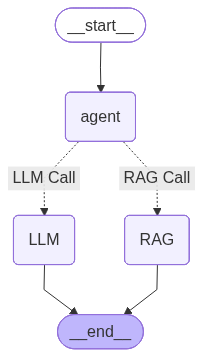

In [92]:
from IPython.display import Image, display

try:
    display(Image(app5.get_graph().draw_mermaid_png()))
except Exception as e:
    # This requires some extra dependencies and is optional
    print(e)

In [93]:
inputs = {"messages": ["Tell me about India's Industrial Growth"]}

In [94]:
outputs = app5.invoke(inputs)

Tell me about India's Industrial Growth


OutputParserException: Invalid json output: India
{
  "Topic": "India",
  "Reasoning": "User query is related to India's Industrial Growth"
}
For troubleshooting, visit: https://python.langchain.com/docs/troubleshooting/errors/OUTPUT_PARSING_FAILURE 

In [95]:
output

{'RAGtool': {'messages': ['Tell me about llama3 model',
   "Llama 3 is a large language model developed by Meta AI. It's designed to understand and generate human-like text, with improved capabilities in reasoning, nuance, and context.",
   'Llama 3 has improved capabilities in reasoning, nuance, and context.']}}

In [96]:
inputs = {"messages": ["Tell me about first prime minister of india?"]}

In [97]:
output = app5.invoke(inputs)

Tell me about first prime minister of india?


OutputParserException: Invalid json output: India
{
  "Topic": "first prime minister of india",
  "Reasoning": "The query specifically asks about the first prime minister of India, indicating a strong relevance to the topic."
}
For troubleshooting, visit: https://python.langchain.com/docs/troubleshooting/errors/OUTPUT_PARSING_FAILURE 

In [98]:
inputs = {"messages": ["who build the Taj Mahal?"]}

In [99]:
output = app5.invoke(inputs)

who build the Taj Mahal?
Topic='India' Reasoning='The question is about the Taj Mahal, which is located in India.'
-> Router ->
India
-> Calling RAG ->
who build the Taj Mahal?
input_variables=['context', 'question'] input_types={} partial_variables={} messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='Answer the question based only on the following context:\n    {context}\n\n    Question: {question}\n    '), additional_kwargs={})]


In [100]:
inputs = {"messages": ["who is president of us?"]}

In [101]:
output = app5.invoke(inputs)

who is president of us?


OutputParserException: Failed to parse TopicSelectionParser from completion "Not Related". Got: 1 validation error for TopicSelectionParser
  Input should be a valid dictionary or instance of TopicSelectionParser [type=model_type, input_value='Not Related', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/model_type
For troubleshooting, visit: https://python.langchain.com/docs/troubleshooting/errors/OUTPUT_PARSING_FAILURE 